[Load] prep_outputs/final_transformed_table_selected.csv | shape=(25403, 85) | positive rate=0.152

[Train] logistic_weight


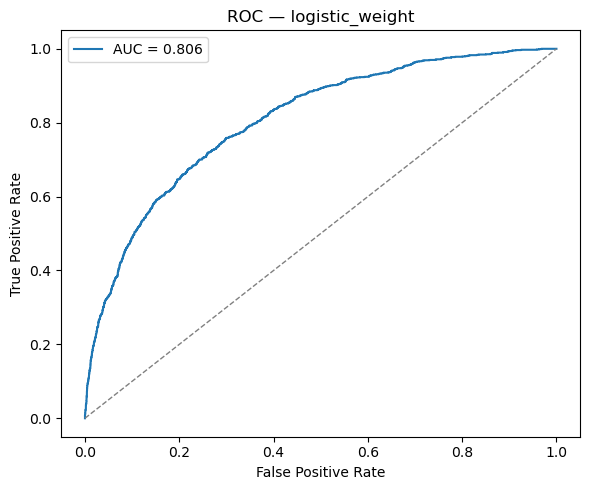

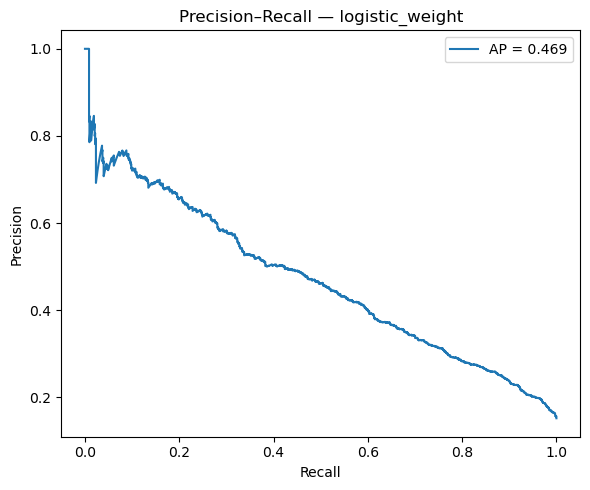

[Test] logistic_weight: AUC=0.806 | AP=0.469
[Thr-MaxF1] logistic_weight: thr=0.618 | Acc=0.813 | P=0.419 | R=0.581 | F1=0.487
[Thr-Recall≥0.70] logistic_weight: thr=0.499 | Acc=0.749 | P=0.342 | R=0.700 | F1=0.459


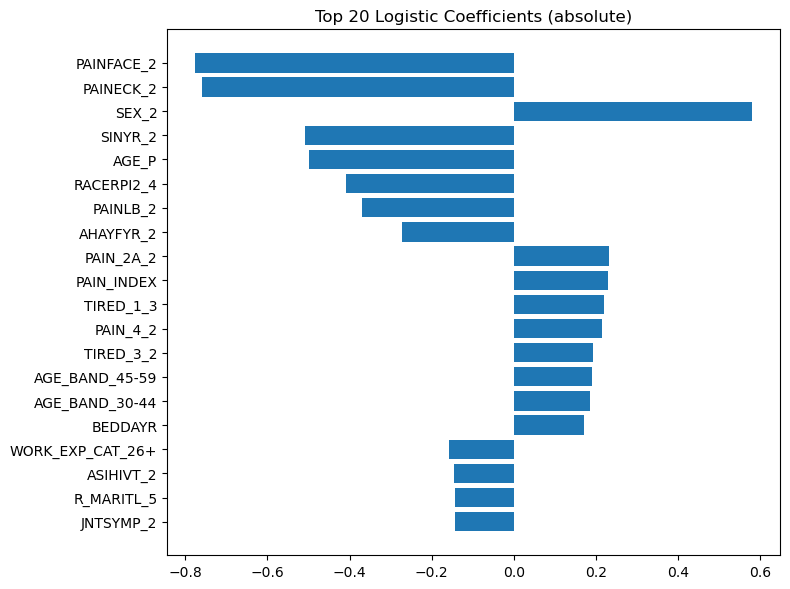


[Train] tree_weight


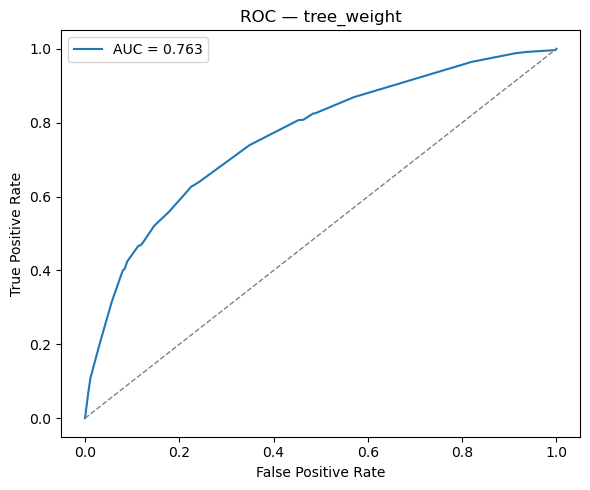

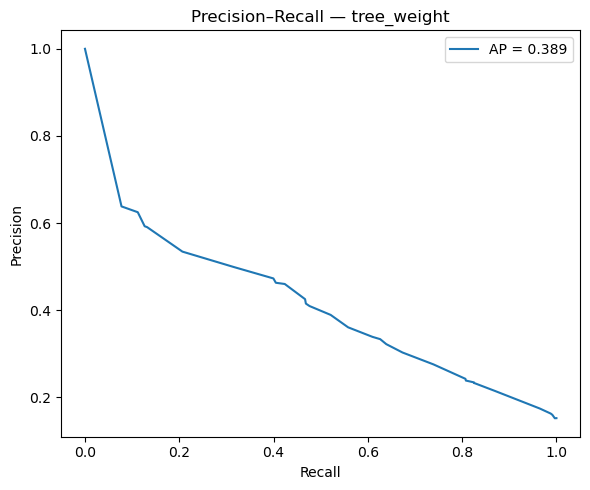

[Test] tree_weight: AUC=0.763 | AP=0.389
[Thr-MaxF1] tree_weight: thr=0.610 | Acc=0.782 | P=0.389 | R=0.521 | F1=0.446
[Thr-Recall≥0.70] tree_weight: thr=0.399 | Acc=0.587 | P=0.276 | R=0.739 | F1=0.373


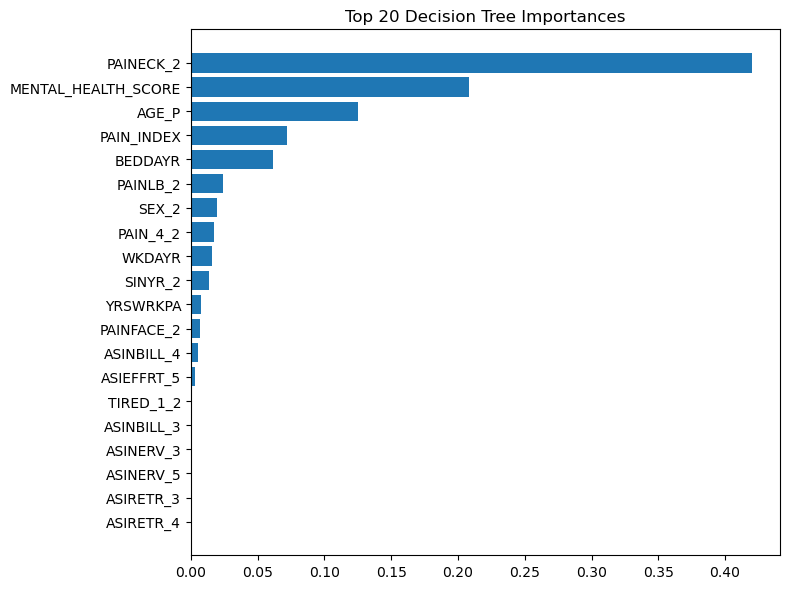


[Train] forest_weight


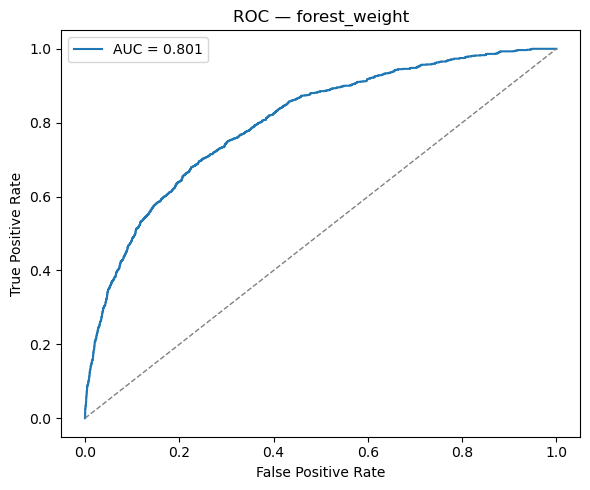

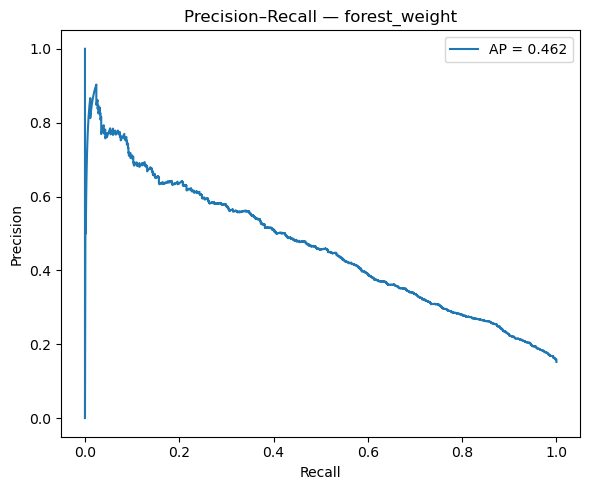

[Test] forest_weight: AUC=0.801 | AP=0.462
[Thr-MaxF1] forest_weight: thr=0.318 | Acc=0.829 | P=0.448 | R=0.532 | F1=0.487
[Thr-Recall≥0.70] forest_weight: thr=0.223 | Acc=0.743 | P=0.336 | R=0.703 | F1=0.455


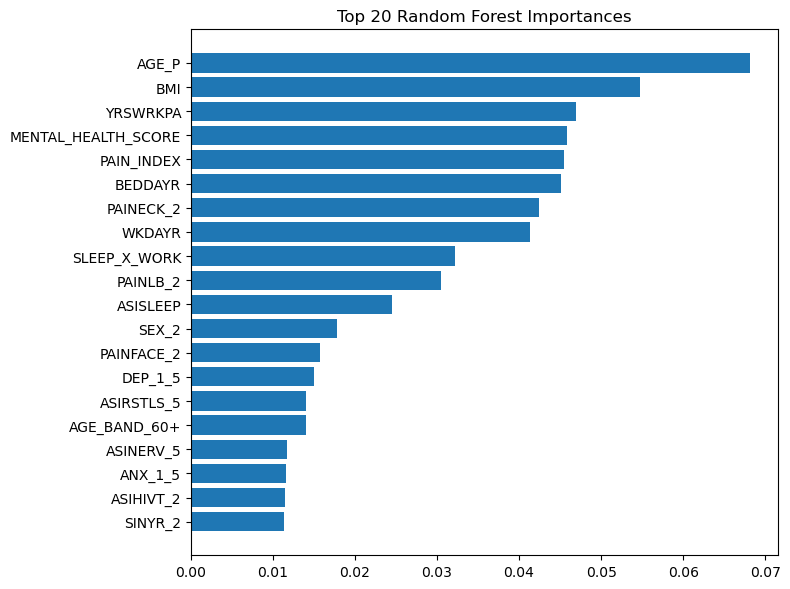


[Train] logistic_ros


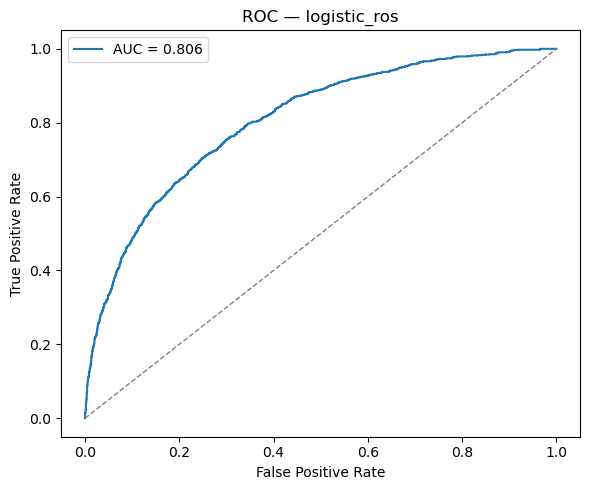

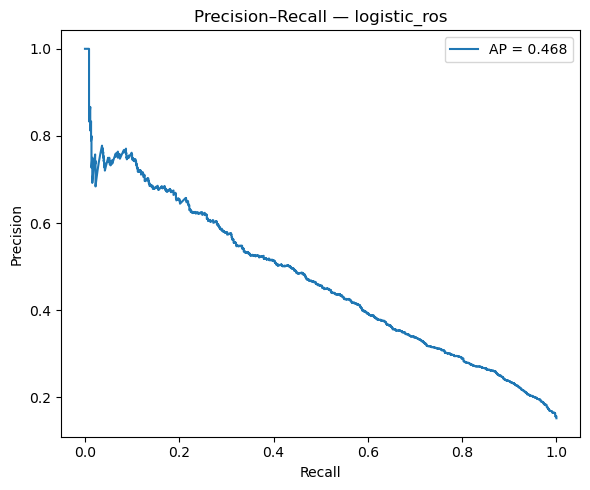

[Test] logistic_ros: AUC=0.806 | AP=0.468
[Thr-MaxF1] logistic_ros: thr=0.635 | Acc=0.818 | P=0.426 | R=0.560 | F1=0.484
[Thr-Recall≥0.70] logistic_ros: thr=0.493 | Acc=0.743 | P=0.336 | R=0.705 | F1=0.456

[Train] tree_ros


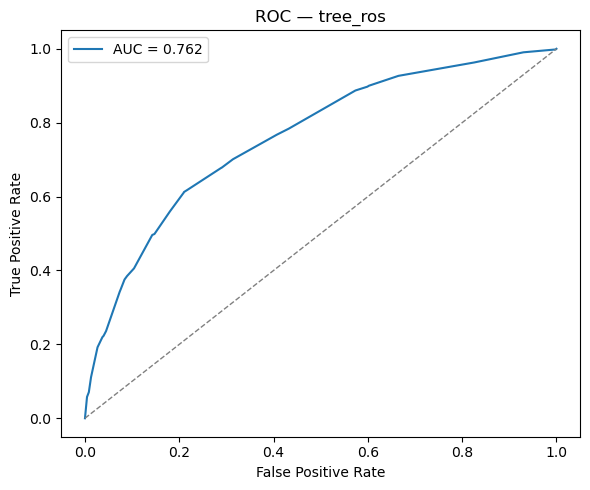

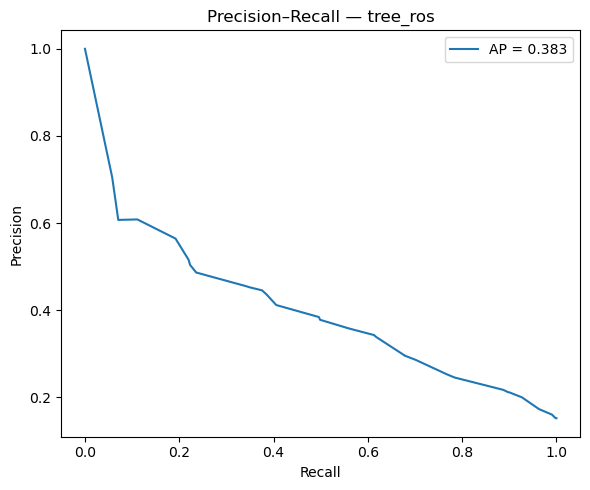

[Test] tree_ros: AUC=0.762 | AP=0.383
[Thr-MaxF1] tree_ros: thr=0.447 | Acc=0.758 | P=0.344 | R=0.612 | F1=0.440
[Thr-Recall≥0.70] tree_ros: thr=0.391 | Acc=0.620 | P=0.286 | R=0.701 | F1=0.381

[Train] forest_ros


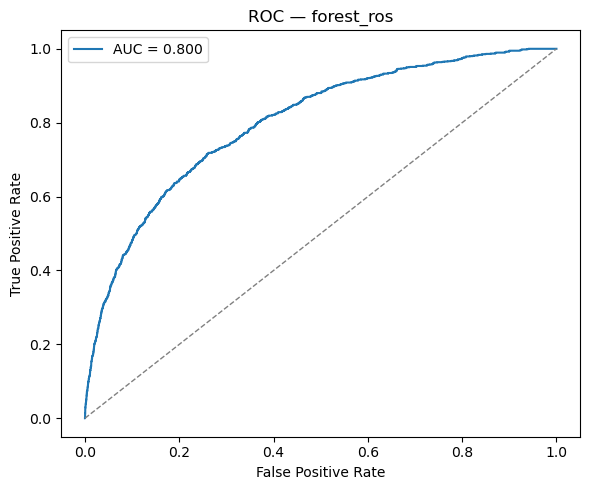

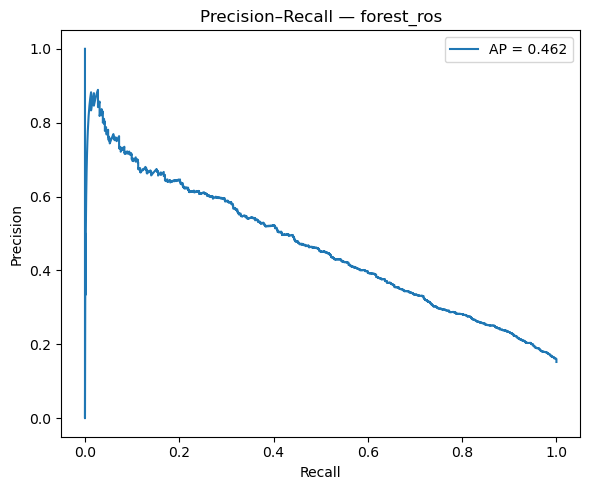

[Test] forest_ros: AUC=0.800 | AP=0.462
[Thr-MaxF1] forest_ros: thr=0.338 | Acc=0.817 | P=0.423 | R=0.556 | F1=0.480
[Thr-Recall≥0.70] forest_ros: thr=0.245 | Acc=0.737 | P=0.332 | R=0.715 | F1=0.453

[Train] logistic_rus


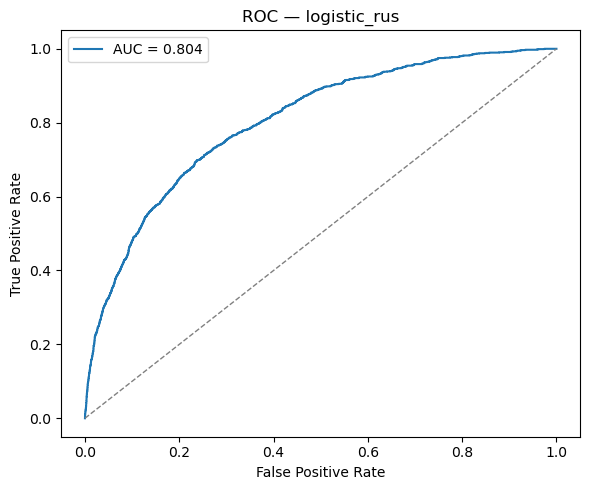

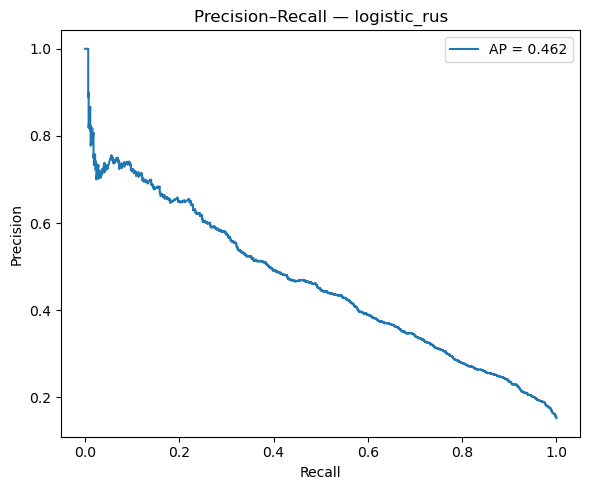

[Test] logistic_rus: AUC=0.804 | AP=0.462
[Thr-MaxF1] logistic_rus: thr=0.644 | Acc=0.822 | P=0.434 | R=0.545 | F1=0.483
[Thr-Recall≥0.70] logistic_rus: thr=0.494 | Acc=0.742 | P=0.336 | R=0.712 | F1=0.457

[Train] tree_rus


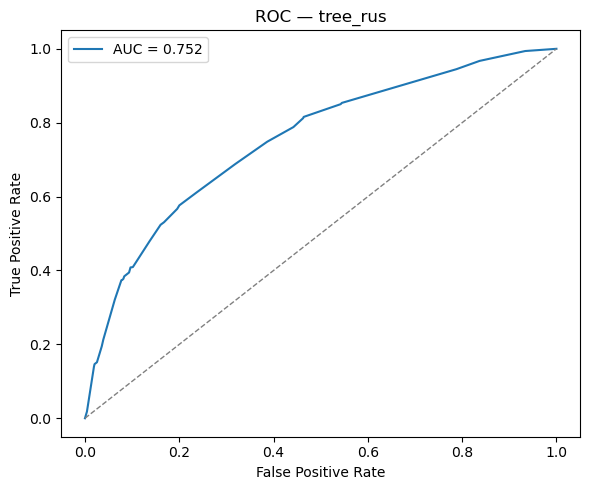

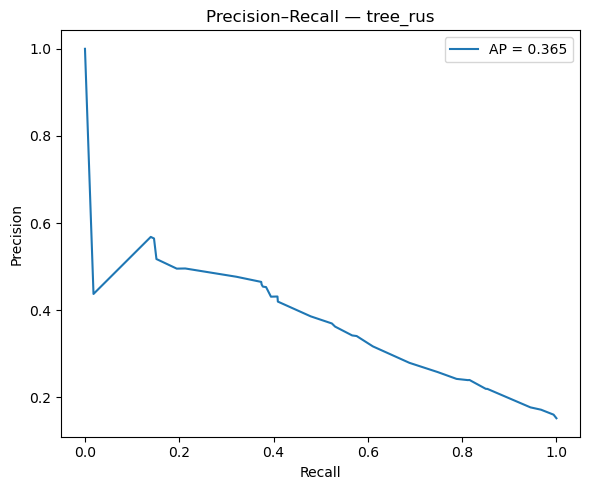

[Test] tree_rus: AUC=0.752 | AP=0.365
[Thr-MaxF1] tree_rus: thr=0.625 | Acc=0.786 | P=0.370 | R=0.524 | F1=0.434
[Thr-Recall≥0.70] tree_rus: thr=0.299 | Acc=0.518 | P=0.240 | R=0.816 | F1=0.349

[Train] forest_rus


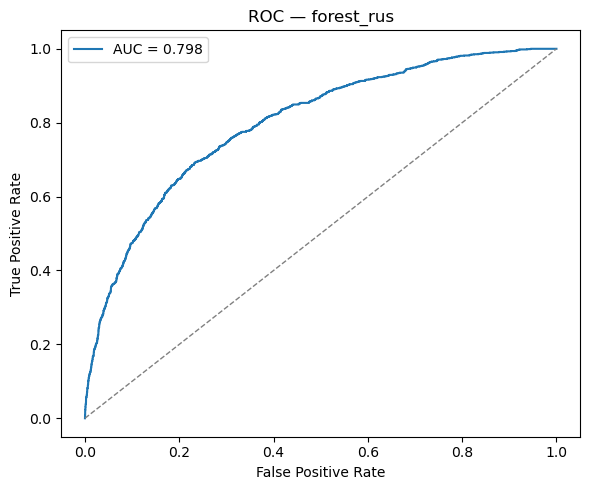

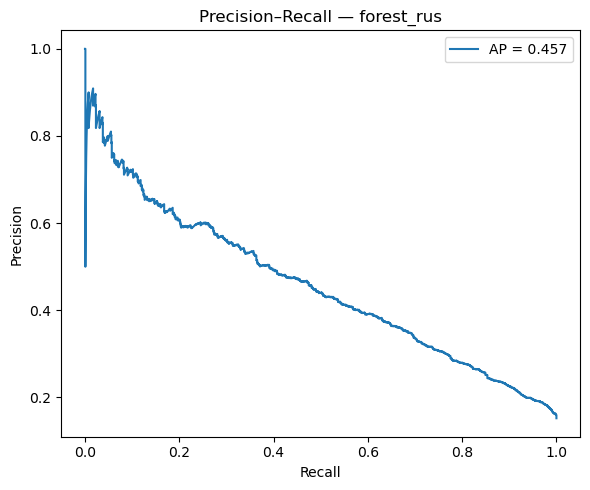

[Test] forest_rus: AUC=0.798 | AP=0.457
[Thr-MaxF1] forest_rus: thr=0.583 | Acc=0.796 | P=0.391 | R=0.611 | F1=0.477
[Thr-Recall≥0.70] forest_rus: thr=0.516 | Acc=0.744 | P=0.337 | R=0.700 | F1=0.454

[Train] logistic_smote


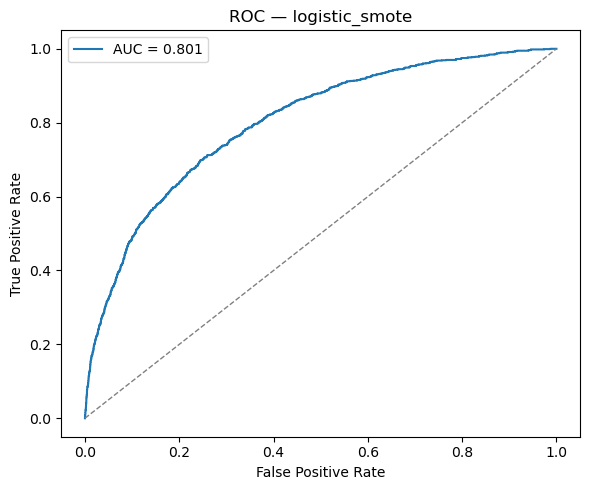

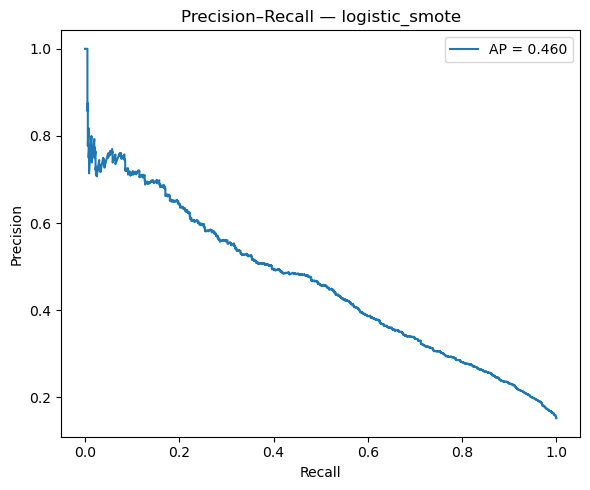

[Test] logistic_smote: AUC=0.801 | AP=0.460
[Thr-MaxF1] logistic_smote: thr=0.668 | Acc=0.829 | P=0.448 | R=0.525 | F1=0.484
[Thr-Recall≥0.70] logistic_smote: thr=0.498 | Acc=0.741 | P=0.334 | R=0.705 | F1=0.453

[Train] tree_smote


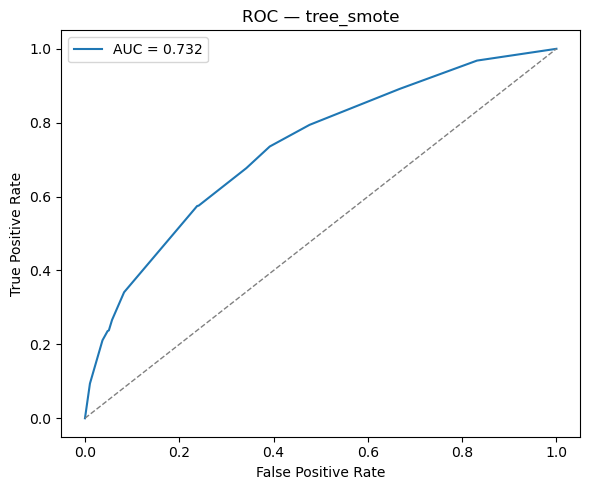

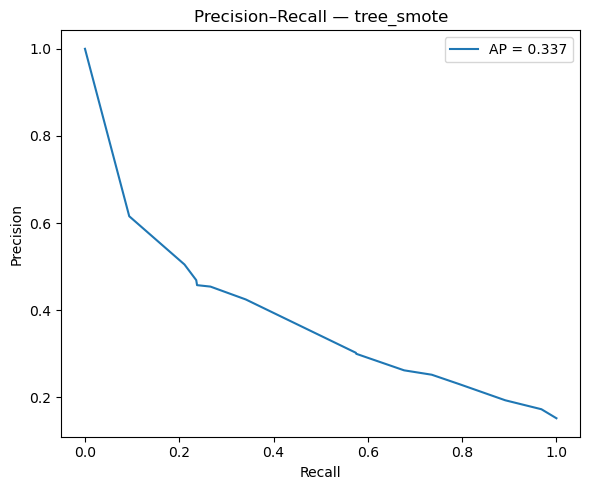

[Test] tree_smote: AUC=0.732 | AP=0.337
[Thr-MaxF1] tree_smote: thr=0.393 | Acc=0.731 | P=0.303 | R=0.575 | F1=0.396
[Thr-Recall≥0.70] tree_smote: thr=0.200 | Acc=0.565 | P=0.252 | R=0.736 | F1=0.357

[Train] forest_smote


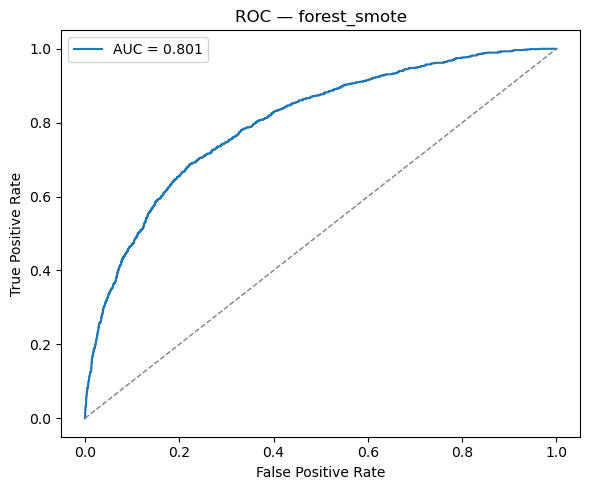

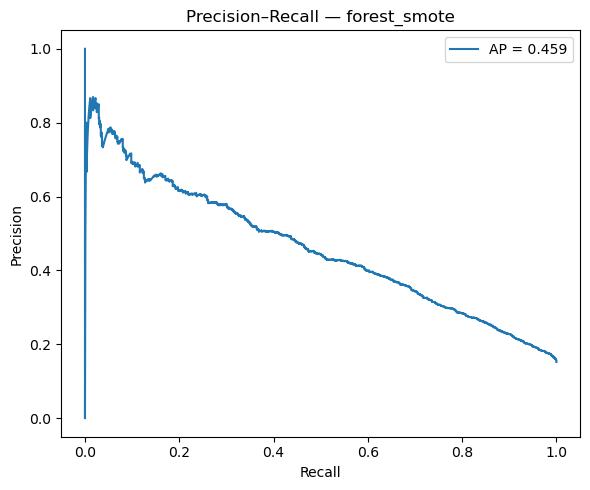

[Test] forest_smote: AUC=0.801 | AP=0.459
[Thr-MaxF1] forest_smote: thr=0.309 | Acc=0.810 | P=0.413 | R=0.587 | F1=0.485
[Thr-Recall≥0.70] forest_smote: thr=0.239 | Acc=0.750 | P=0.344 | R=0.703 | F1=0.462

[OK] Saved with strategies (weight/ros/rus/smote):
 - prep_outputs/dm_metrics_summary.csv
 - prep_outputs/dm_threshold_report.csv
 - prep_outputs/dm_threshold_recall_priority.csv


In [7]:
# ============================================================
# 7. Data Mining — final, reproducible model training & evaluation
# ============================================================

import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_recall_curve, roc_curve,
    precision_score, recall_score, f1_score, confusion_matrix, accuracy_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# -----------------------------
# 0) Paths & I/O
# -----------------------------
os.makedirs("prep_outputs", exist_ok=True)
os.makedirs("figs", exist_ok=True)

IN = "prep_outputs/final_transformed_table_selected.csv"
assert os.path.exists(IN), f"Input not found: {IN}"
df = pd.read_csv(IN)

# -----------------------------
# 1) Data split (shared, reproducible)
# -----------------------------
RID_COL, TARGET_COL = "RID", "AMIGR"
X = df.drop(columns=[RID_COL, TARGET_COL])
y = (df[TARGET_COL] == 1).astype(int)  # NHIS coding: 1=Yes, 2=No

# Stratified split to preserve class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
print(f"[Load] {IN} | shape={df.shape} | positive rate={y.mean():.3f}")

# -----------------------------
# 2) Helper functions
# -----------------------------
def best_threshold_f1(y_true, y_proba):
    """Find threshold that maximizes F1 on the precision–recall curve."""
    p, r, thr = precision_recall_curve(y_true, y_proba)
    thr = np.r_[0, thr]  # align length with p/r
    f1 = 2 * p * r / (p + r + 1e-12)
    i = np.nanargmax(f1)
    return float(thr[i]), float(p[i]), float(r[i]), float(f1[i])

def threshold_for_target_recall(y_true, y_proba, target_recall=0.70):
    """Select smallest threshold that achieves recall >= target_recall."""
    p, r, thr = precision_recall_curve(y_true, y_proba)
    thr = np.r_[0, thr]
    mask = (r >= target_recall)
    if not np.any(mask):
        i = np.argmax(r)  # fallback to maximum recall
    else:
        cand = np.where(mask)[0]
        i = cand[np.argmax((p[mask] * r[mask]))]
    return float(thr[i]), float(p[i]), float(r[i])

def evaluate_at_threshold(y_true, y_proba, thr):
    """Compute accuracy, precision, recall, F1 and confusion matrix at a threshold."""
    y_pred = (y_proba >= thr).astype(int)
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {"threshold": thr, "accuracy": acc, "precision": prec, "recall": rec,
            "f1": f1, "tp": int(tp), "fp": int(fp), "tn": int(tn), "fn": int(fn)}

def plot_roc_pr_curves(y_true, y_proba, name_prefix):
    """Plot ROC and PR curves, save them to figs/, and export curve points to CSV."""
    # ROC curve
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    auc = roc_auc_score(y_true, y_proba)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
    plt.plot([0,1],[0,1],"--",lw=1,color="gray")
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title(f"ROC — {name_prefix}"); plt.legend(); plt.tight_layout()
    plt.savefig(f"figs/fig_7_roc_{name_prefix}.png", dpi=200)
    plt.show()
    pd.DataFrame({"fpr": fpr, "tpr": tpr}).to_csv(
        f"prep_outputs/dm_curves_{name_prefix}_roc.csv", index=False
    )

    # PR curve
    p, r, _ = precision_recall_curve(y_true, y_proba)
    ap = average_precision_score(y_true, y_proba)
    plt.figure(figsize=(6,5))
    plt.plot(r, p, label=f"AP = {ap:.3f}")
    plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.title(f"Precision–Recall — {name_prefix}"); plt.legend(); plt.tight_layout()
    plt.savefig(f"figs/fig_7_pr_{name_prefix}.png", dpi=200)
    plt.show()
    pd.DataFrame({"recall": r, "precision": p}).to_csv(
        f"prep_outputs/dm_curves_{name_prefix}_pr.csv", index=False
    )
    return auc, ap

def save_cm_csv(y_true, y_proba, thr, name):
    """Save confusion matrix values at a given threshold to CSV."""
    y_hat = (y_proba >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_hat).ravel()
    pd.DataFrame({"metric": ["TP","FP","FN","TN"], "value": [tp, fp, fn, tn]}).to_csv(
        f"prep_outputs/cm_{name}_thr_{thr:.3f}.csv", index=False
    )

# -----------------------------
# 3) Models + imbalance strategies
# -----------------------------
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler

base_models = {
    "logistic": LogisticRegression(
        solver="saga", penalty="l1", C=0.1,
        class_weight=None,   # will manage imbalance via strategy, not weight
        max_iter=2000, n_jobs=-1, random_state=42
    ),
    "tree": DecisionTreeClassifier(
        max_depth=5, min_samples_split=2, min_samples_leaf=1,
        class_weight=None, random_state=42
    ),
    "forest": RandomForestClassifier(
        n_estimators=400, max_depth=None, min_samples_split=5,
        class_weight=None, n_jobs=-1, random_state=42
    ),
}

def make_estimator(model, strategy):
    """
    Return an estimator per imbalance strategy:
      - 'weight' : original baseline using class_weight='balanced'
      - 'ros'    : RandomOverSampler on train only
      - 'rus'    : RandomUnderSampler on train only
      - 'smote'  : SMOTE on train only
    """
    if strategy == "weight":
        # clone model and turn on class_weight='balanced'
        m = type(model)(**{**model.get_params(), "class_weight": "balanced"})
        return m

    if strategy == "ros":
        return ImbPipeline([("ros", RandomOverSampler(random_state=42)), ("clf", model)])

    if strategy == "rus":
        return ImbPipeline([("rus", RandomUnderSampler(random_state=42)), ("clf", model)])

    if strategy == "smote":
        # SMOTE needs numeric features; your table is model-ready (dummies), so it's fine
        return ImbPipeline([("smote", SMOTE(k_neighbors=5, random_state=42)), ("clf", model)])

    raise ValueError("Unknown strategy")

strategies = ["weight", "ros", "rus", "smote"]  # compare all four


# -----------------------------
# 4) Train, evaluate, thresholds, plots, CMs (by strategy × model)
# -----------------------------
rows_metrics, rows_thr_maxf1, rows_thr_recall = [], [], []

for strat in strategies:
    for name, base in base_models.items():
        tag = f"{name}_{strat}"
        print(f"\n[Train] {tag}")

        est = make_estimator(base, strat)
        est.fit(X_train, y_train)

        # predict_proba works for all here (in pipeline: step is 'clf')
        if isinstance(est, ImbPipeline):
            proba_test = est.named_steps["clf"].predict_proba(X_test)[:, 1]
        else:
            proba_test = est.predict_proba(X_test)[:, 1]

        # curves
        auc, ap = plot_roc_pr_curves(y_test, proba_test, name_prefix=tag)
        print(f"[Test] {tag}: AUC={auc:.3f} | AP={ap:.3f}")

        # (A) Max-F1
        thr_f1, p_f1, r_f1, f1_f1 = best_threshold_f1(y_test, proba_test)
        eval_f1 = evaluate_at_threshold(y_test, proba_test, thr_f1)
        print(f"[Thr-MaxF1] {tag}: thr={thr_f1:.3f} | Acc={eval_f1['accuracy']:.3f} "
              f"| P={p_f1:.3f} | R={r_f1:.3f} | F1={f1_f1:.3f}")
        save_cm_csv(y_test, proba_test, thr_f1, f"{tag}_maxf1")

        # (B) Recall ≥ 0.70
        thr_rec, p_rec, r_rec = threshold_for_target_recall(y_test, proba_test, target_recall=0.70)
        eval_rec = evaluate_at_threshold(y_test, proba_test, thr_rec)
        print(f"[Thr-Recall≥0.70] {tag}: thr={thr_rec:.3f} | Acc={eval_rec['accuracy']:.3f} "
              f"| P={p_rec:.3f} | R={r_rec:.3f} | F1={eval_rec['f1']:.3f}")
        save_cm_csv(y_test, proba_test, thr_rec, f"{tag}_recall70")

        # summaries
        rows_metrics.append({"model": name, "strategy": strat, "test_auc": auc, "test_ap": ap})
        rows_thr_maxf1.append({"model": name, "strategy": strat, **eval_f1})
        rows_thr_recall.append({"model": name, "strategy": strat, **eval_rec})

        # interpretability plots (only once per model for cleanliness – use ‘weight’ as canonical)
        if strat == "weight":
            if name == "logistic":
                coef = est.coef_.ravel() if not isinstance(est, ImbPipeline) else est.named_steps["clf"].coef_.ravel()
                feats = np.array(X.columns)
                order = np.argsort(np.abs(coef))[::-1][:20]
                plt.figure(figsize=(8,6)); plt.barh(feats[order][::-1], coef[order][::-1])
                plt.title("Top 20 Logistic Coefficients (absolute)")
                plt.tight_layout(); plt.savefig("figs/fig_7_coeffs_logreg.png", dpi=200); plt.show()
            elif name == "tree":
                imp = est.feature_importances_ if not isinstance(est, ImbPipeline) else est.named_steps["clf"].feature_importances_
                feats = np.array(X.columns); order = np.argsort(imp)[::-1][:20]
                plt.figure(figsize=(8,6)); plt.barh(feats[order][::-1], imp[order][::-1])
                plt.title("Top 20 Decision Tree Importances")
                plt.tight_layout(); plt.savefig("figs/fig_7_importance_tree.png", dpi=200); plt.show()
            elif name == "forest":
                imp = est.feature_importances_ if not isinstance(est, ImbPipeline) else est.named_steps["clf"].feature_importances_
                feats = np.array(X.columns); order = np.argsort(imp)[::-1][:20]
                plt.figure(figsize=(8,6)); plt.barh(feats[order][::-1], imp[order][::-1])
                plt.title("Top 20 Random Forest Importances")
                plt.tight_layout(); plt.savefig("figs/fig_7_importance_forest.png", dpi=200); plt.show()

# -----------------------------
# 5) Persist reports (now include strategy)
# -----------------------------
pd.DataFrame(rows_metrics).to_csv("prep_outputs/dm_metrics_summary.csv", index=False)
pd.DataFrame(rows_thr_maxf1).to_csv("prep_outputs/dm_threshold_report.csv", index=False)
pd.DataFrame(rows_thr_recall).to_csv("prep_outputs/dm_threshold_recall_priority.csv", index=False)

print("\n[OK] Saved with strategies (weight/ros/rus/smote):")
print(" - prep_outputs/dm_metrics_summary.csv")
print(" - prep_outputs/dm_threshold_report.csv")
print(" - prep_outputs/dm_threshold_recall_priority.csv")